# 23BAI1589 - Yashvanth Karunakaran
## Speech and Language Processing Lab
## Lab 1 - Sentiment Analysis on Amazon Reviews

### Importing the Packages
To get Maximum view of columns setting maximum width

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_colwidth',None)

### Exploring the Dataset

In [2]:
df=pd.read_csv("/content/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv")
df.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batteries (36 Count),"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care",Health & Beauty,"https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%2BkL._SL1500_.jpg,https://images-na.ssl-images-amazon.com/images/I/81ZTa1BrkzL._SL1500_.jpg,http://ecx.images-amazon.com/images/I/41pSoRu7UlL._SS40_.jpg,https://www.upccodesearch.com/images/barcode/0841710106442.png,https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%252525252BkL._SL1500_.jpg,https://images-na.ssl-images-amazon.com/images/I/51DfBuqy4qL._SL1189_.jpg,https://images-na.ssl-images-amazon.com/images/I/51TshsEJTIL.jpg,https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%2525252525252BkL._SL1500_.jpg,https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%25252BkL._SL1500_.jpg,https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%2525252BkL._SL1500_.jpg,https://images-na.ssl-images-amazon.com/images/I/51g3uIwzOIL._SL1050_.jpg,http://ecx.images-amazon.com/images/I/613LUdOc1eL._SS40_.jpg","amazonbasics/hl002619,amazonbasicsaaaperformancealkalinebatteries36count/b00lh3dmuo,0841710106442,841710106442,amazonbasicsaaaperformancealkalinebatteries36count/b00qwo9p0o",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9P0O/,I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.,... 3 of them and one of the item is bad quality. Is missing backup spring so I have ...,Byger yang,"https://www.barcodable.com/upc/841710106442,https://www.amazon.com/AmazonBasics-Performance-Alkaline-Batteries-Count/dp/B00LH3DMUO/,https://www.amazon.com/AmazonBasics-Performance-Alkaline-Batteries-Count/dp/B00LH3DMUO,https://www.amazon.com/AmazonBasics-Performance-Alkaline-Batteries-36-Pack/dp/B00LH3DMUO/,http://www.amazon.com/AmazonBasics-Performance-Alkaline-Batteries-36-Pack/dp/B00LH3DMUO"
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batteries (36 Count),"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care",Health & Beauty,"https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%2BkL._SL1500_.jpg,https://images-na.ssl-images-amazon.com/images/I/81ZTa1BrkzL._SL1500_.jpg,http://ecx.images-amazon.com/images/I/41pSoRu7UlL._SS40_.jpg,https://www.upccodesearch.com/images/barcode/0841710106442.png,https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%252525252BkL._SL1500_.jpg,https://images-na.ssl-images-amazon.com/images/I/51DfBuqy4qL._SL1189_.jpg,https://images-na.ssl-images-amazon.com/images/I/51TshsEJTIL.jpg,https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%2525252525252BkL._SL1500_.jpg,https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%25252BkL._SL1500_.jpg,https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%2525252BkL._SL1500_.jpg,https://images-na.ssl-images-amazon.com/images/I/51g3uIwzOIL._SL1050_.jpg,http://ecx.images-amazon.com/images/I/613LUdOc1eL._SS40_.jpg","amazonbasics/hl002619,amazonbasicsaaaperformancealkalinebatteries36count/b00lh3dmuo,0841710106442,841710106442,amazonbasicsaaaperformancealkalinebatteries36count/b00qwo9p0o",...,NaN,NaN,NaN,NaN,4,https://www.amazon.c

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28332 entries, 0 to 28331
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   28332 non-null  object 
 1   dateAdded            28332 non-null  object 
 2   dateUpdated          28332 non-null  object 
 3   name                 28332 non-null  object 
 4   asins                28332 non-null  object 
 5   brand                28332 non-null  object 
 6   categories           28332 non-null  object 
 7   primaryCategories    28332 non-null  object 
 8   imageURLs            28332 non-null  object 
 9   keys                 28332 non-null  object 
 10  manufacturer         28332 non-null  object 
 11  manufacturerNumber   28332 non-null  object 
 12  reviews.date         28332 non-null  object 
 13  reviews.dateSeen     28332 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doRecommend  16086 non-null 

### Keeping only necessary key columns

In [4]:
key_cols=['reviews.text','reviews.rating','reviews.title','brand','categories','primaryCategories','name','reviews.numHelpful']
df=df[key_cols]
df.head()

,reviews.text,reviews.rating,reviews.title,brand,categories,primaryCategories,name,reviews.numHelpful
0,I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.,3,... 3 of them and one of the item is bad quality. Is missing backup spring so I have ...,Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care",Health & Beauty,AmazonBasics AAA Performance Alkaline Batteries (36 Count),NaN
1,Bulk is always the less expensive way to go for products like these,4,... always the less expensive way to go for products like,Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care",Health & Beauty,AmazonBasics AAA Performance Alkaline Batteries (36 Count),NaN
2,Well they are not Duracell but for the price i am happy.,5,... are not Duracell but for the price i am happy.,Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care",Health & Beauty,AmazonBasics AAA Performance Alkaline Batteries (36 Count),NaN
3,Seem to work as well as name brand batteries at a much better price,5,... as well as name brand batteries at a much better,Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care",Health & Beauty,AmazonBasics AAA Performance Alkaline Batteries (36 Count),NaN
4,These batteries are very long lasting the price is great.,5,... batteries are very long lasting the price is great.,Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care",Health & Beauty,AmazonBasics AAA Performance Alkaline Batteries (36 Count),NaN


### Checking for null values

In [5]:
df.isnull().sum()

,0
reviews.text,0
reviews.rating,0
reviews.title,0
brand,0
categories,0
primaryCategories,0
name,0
reviews.numHelpful,12217


### Assigning Sentiment based on Rating
#### Rating >=4 means Positive Review
#### Rating ==3 means Neutral Review
#### Rating <3 means Negative Review

In [6]:
def rating_sentiment(rating):
  if rating>=4: return "positive"
  if rating==3: return "neutral"
  return "negative"
df['rating_sentiment']=df['reviews.rating'].apply(rating_sentiment)
df[['reviews.rating','rating_sentiment']].head()

,reviews.rating,rating_sentiment
0,3,neutral
1,4,positive
2,5,positive
3,5,positive
4,5,positive


### Rating Sentiment Distribution
#### Distribution of positive, neutral and negative reviews

In [7]:
df['rating_sentiment'].value_counts()

,count
rating_sentiment,
positive,25545
negative,1581
neutral,1206


### Checking Whether Sentiment is Correct with the Reviews

In [8]:
df[['reviews.title','reviews.text','reviews.rating','rating_sentiment']].head()

,reviews.title,reviews.text,reviews.rating,rating_sentiment
0,... 3 of them and one of the item is bad quality. Is missing backup spring so I have ...,I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.,3,neutral
1,... always the less expensive way to go for products like,Bulk is always the less expensive way to go for products like these,4,positive
2,... are not Duracell but for the price i am happy.,Well they are not Duracell but for the price i am happy.,5,positive
3,... as well as name brand batteries at a much better,Seem to work as well as name brand batteries at a much better price,5,positive
4,... batteries are very long lasting the price is great.,These batteries are very long lasting the price is great.,5,positive


### Extracting Brand Information

In [9]:
df['brand'].value_counts()

,count
brand,
Amazon,16153
Amazonbasics,12169
AmazonBasics,10


### AmazonBasics and Amazonbasics are Same

In [10]:
df['brand']=df['brand'].replace({'Amazonbasics':'AmazonBasics'})
df['brand'].value_counts()

,count
brand,
Amazon,16153
AmazonBasics,12179


### Checking Categories Information

In [11]:
df['categories'].value_counts().head()

,count
categories,
"AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care",8343
"AA,AAA,Electronics Features,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care",3728
"Fire Tablets,Tablets,All Tablets,Amazon Tablets,Genuine Tablet Accessories,Computers & Tablets,Electronics,Amazon",2443
"Fire Tablets,Tablets,All Tablets,Amazon Tablets,Computers & Tablets",2407
"Fire Tablets,Computers/Tablets & Networking,Electronics Features,Tablets,All Tablets,Amazon Tablets,Computers & Tablets,Electronics,iPad & Tablets,Tablets & eBook Readers",2370


### Parsing Primary Categories

In [12]:
import numpy as np
def parsing_categories(categories):
  return list(set(categories.split(',')))
df['parsed_categories']=df['primaryCategories'].apply(parsing_categories)
df['parsed_categories'].value_counts().head()

,count
parsed_categories,
[Electronics],13995
[Health & Beauty],12071
"[Toys & Games, Electronics]",1676
"[Office Supplies, Electronics]",386
"[Media, Electronics]",185


### VADER customization with Domain specific terms

In [13]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [14]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
analyzer=SentimentIntensityAnalyzer()
domain_lexicon={
    'responsive':2.0,
    'vibrant':2.0,
    'ergonomic':2.0,
    'seamless':2.0,
    'glitchy':-2.5,
    'laggy':-2.5,
    'overheats':-3.0,
    'blurry':-2.0,
    'sturdy':1.5,
    'intuitive':2.0,
    'clunky':-2.0,
    'bloatware':-2.0,
    'crisp':1.5,
    'dim':-1.5
}
analyzer.lexicon.update(domain_lexicon)

### Assigning Sentiment as per VADER Polarity Score
Checking Reviews Matching with VADER Sentiment

In [15]:
def vader_sentiment(txt):
  score=analyzer.polarity_scores(txt)['compound']
  if score>=0.05: return 'positive'
  if score<=-0.05: return 'negative'
  return 'neutral'
df['vader_sentiment']=df['reviews.text'].apply(vader_sentiment)
df[['reviews.text','vader_sentiment']].head()

,reviews.text,vader_sentiment
0,I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.,negative
1,Bulk is always the less expensive way to go for products like these,positive
2,Well they are not Duracell but for the price i am happy.,positive
3,Seem to work as well as name brand batteries at a much better price,positive
4,These batteries are very long lasting the price is great.,positive


### VADER sentiment distribution

In [16]:
df['vader_sentiment'].value_counts()

,count
vader_sentiment,
positive,23717
neutral,2492
negative,2123


### Accuracy between Rating and VADER Sentiment
83.21% Accurate

In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(df['rating_sentiment'],df['vader_sentiment'])

0.8321332768600875

### Combining Review Title and Reviews Text for more accurate sentiment

In [18]:
df['full_review']=df['reviews.title']+' '+df['reviews.text']
df['full_review'].head()

,full_review
0,... 3 of them and one of the item is bad quality. Is missing backup spring so I have ... I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.
1,... always the less expensive way to go for products like Bulk is always the less expensive way to go for products like these
2,... are not Duracell but for the price i am happy. Well they are not Duracell but for the price i am happy.
3,... as well as name brand batteries at a much better Seem to work as well as name brand batteries at a much better price
4,... batteries are very long lasting the price is great. These batteries are very long lasting the price is great.


### Finding VADER sentiment for combined title and text review

In [19]:
df['vader_sentiment']=df['full_review'].apply(vader_sentiment)
df[['full_review','vader_sentiment']].head()

,full_review,vader_sentiment
0,... 3 of them and one of the item is bad quality. Is missing backup spring so I have ... I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.,negative
1,... always the less expensive way to go for products like Bulk is always the less expensive way to go for products like these,positive
2,... are not Duracell but for the price i am happy. Well they are not Duracell but for the price i am happy.,positive
3,... as well as name brand batteries at a much better Seem to work as well as name brand batteries at a much better price,positive
4,... batteries are very long lasting the price is great. These batteries are very long lasting the price is great.,positive


### Accuracy Score between Rating and VADER Sentiment

In [20]:
accuracy_score(df['rating_sentiment'],df['vader_sentiment'])

0.8705350840039531

### Removing Stop words and Lemmatizing the words to increase accuracy further
Lemmatizer converts words like running to run.
Stop words like i am, the, was etc.. will be removed

In [21]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Creating Preprocessed Review and Comparing with Original Review
#### Tokenzing review text as words
#### Lemmatizing the words
#### Removing Stop words

In [22]:
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

def preprocess_text(text):
  words=word_tokenize(text)
  words=[lemmatizer.lemmatize(word) for word in words if word.isalnum()]
  words=[word for word in words if word not in stop_words]
  return ' '.join(words)

df['preprocessed_text']=df['full_review'].apply(preprocess_text)
df[['full_review','preprocessed_text']].head()

,full_review,preprocessed_text
0,... 3 of them and one of the item is bad quality. Is missing backup spring so I have ... I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.,3 one item bad quality Is missing backup spring I I order 3 one item bad quality Is missing backup spring I put pc aluminum make battery work
1,... always the less expensive way to go for products like Bulk is always the less expensive way to go for products like these,always less expensive way go product like Bulk always less expensive way go product like
2,... are not Duracell but for the price i am happy. Well they are not Duracell but for the price i am happy.,Duracell price happy Well Duracell price happy
3,... as well as name brand batteries at a much better Seem to work as well as name brand batteries at a much better price,well name brand battery much better Seem work well name brand battery much better price
4,... batteries are very long lasting the price is great. These batteries are very long lasting the price is great.,battery long lasting price great These battery long lasting price great


### Replacing emojis with a empty string for efficient training with nltk package

In [23]:
!pip install demoji

In [24]:
import demoji

def remove_emojis(text):
  return demoji.replace(text,'')

df['preprocessed_text']=df['preprocessed_text'].apply(remove_emojis)
df[['full_review','preprocessed_text']].head()

,full_review,preprocessed_text
0,... 3 of them and one of the item is bad quality. Is missing backup spring so I have ... I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.,3 one item bad quality Is missing backup spring I I order 3 one item bad quality Is missing backup spring I put pc aluminum make battery work
1,... always the less expensive way to go for products like Bulk is always the less expensive way to go for products like these,always less expensive way go product like Bulk always less expensive way go product like
2,... are not Duracell but for the price i am happy. Well they are not Duracell but for the price i am happy.,Duracell price happy Well Duracell price happy
3,... as well as name brand batteries at a much better Seem to work as well as name brand batteries at a much better price,well name brand battery much better Seem work well name brand battery much better price
4,... batteries are very long lasting the price is great. These batteries are very long lasting the price is great.,battery long lasting price great These battery long lasting price great


### Finding VADER sentiment for the preprocessed text

In [25]:
df['vader_sentiment']=df['preprocessed_text'].apply(vader_sentiment)
df[['preprocessed_text','vader_sentiment']].head()

,preprocessed_text,vader_sentiment
0,3 one item bad quality Is missing backup spring I I order 3 one item bad quality Is missing backup spring I put pc aluminum make battery work,negative
1,always less expensive way go product like Bulk always less expensive way go product like,positive
2,Duracell price happy Well Duracell price happy,positive
3,well name brand battery much better Seem work well name brand battery much better price,positive
4,battery long lasting price great These battery long lasting price great,positive


### Accuracy between Rating and VADER sentiment for preprocessed text

In [26]:
accuracy_score(df['rating_sentiment'],df['vader_sentiment'])

0.8737822956374418

### Extracting Features for the Products based on Categories

In [27]:
df['parsed_categories'].value_counts()

,count
parsed_categories,
[Electronics],13995
[Health & Beauty],12071
"[Toys & Games, Electronics]",1676
"[Office Supplies, Electronics]",386
"[Media, Electronics]",185
[Office Supplies],9
[Animals & Pet Supplies],6
[Home & Garden],2
"[Furniture, Electronics]",2


### Creating General Category and Feature Mapping
#### For extracting the features for the product based on the Category they belong
#### Based on these features we can extract top 5 praised, complaint and mentioned features for the product in the review
#### Adding general features mentioned in each category

In [28]:
import re

category_features={
    'Electronics':['battery','screen','charging','durability','performance','display','design','port'],
    'Tablets':['screen','display','battery','performance','speakers','cameras', 'weight','kids mode'],
    'Headphones':['sound','bass','comfort','noise cancellation','battery','bluetooth','fit'],
    'Smart Home':['connectivity','app','voice recognition','alexa','setup','wifi','speaker'],
    'E-Readers':['screen','glare','battery','reading','light','storage','page turn'],
    'Health & Beauty':['skin','smell','ingredients','texture','rash','packaging','usage','application','batteries'],
    'Toys & Games':['durability','safety','battery','fun','controls','age appropriate','sturdy'],
    'Office Supplies':['ink','paper','printing','durability','binding','size','color'],
    'Media':['content', 'selection','streaming','quality','interface','ads'],
    'Animals & Pet Supplies':['size','material','durability','scent','cleanup','fit'],
    'Home & Garden':['quality','size','assembly','instructions','material','decor'],
    'Furniture':['assembly','comfort','sturdiness','finish','size', 'material']
}
default_features = ['price','quality','shipping','packaging','value','service']

### Assigning Features for Product Based on Category
#### For each instance take the parsed category of that instance and then assign the general features as give above
#### Checking whether the extracted feature is present in the review text or title
#### Taking only mentioned features and returning

In [29]:
def product_feature_extraction(data):
  cat=data.get('parsed_categories',['Electronics'])
  feature_list=default_features.copy()
  for i in cat:
    if i in category_features:
      feature_list.extend(category_features[i])
  text=data['reviews.title'].lower()+" "+data['reviews.text'].lower()
  features=[]
  for feature in feature_list:
    if re.search(r'\b'+re.escape(feature)+r'\b',text):
      features.append(feature)
  return features

#### Applying the Product feature extraction for each instance
#### Exploring whether the mentioned features are correct

In [30]:
df['features']=df.apply(product_feature_extraction,axis=1)
df[['reviews.text','primaryCategories','rating_sentiment','features']].head()

,reviews.text,primaryCategories,rating_sentiment,features
0,I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.,Health & Beauty,neutral,[quality]
1,Bulk is always the less expensive way to go for products like these,Health & Beauty,positive,[]
2,Well they are not Duracell but for the price i am happy.,Health & Beauty,positive,[price]
3,Seem to work as well as name brand batteries at a much better price,Health & Beauty,positive,"[price, batteries]"
4,These batteries are very long lasting the price is great.,Health & Beauty,positive,"[price, batteries]"


### Exploring Assigned Features Distribution

In [31]:
df['features'].value_counts().head(10)

,count
features,
[],15163
[batteries],3243
[price],2814
"[price, batteries]",1404
[screen],779
[value],671
[quality],433
[battery],380
"[price, quality]",277


### Function to Extract the Top Praised and Complaint Features

#### Taking all the features mentioned in the dataset and taking top 5 for most mentioned features
#### Taking top 5 positive sentiment features for praised
#### Taking top 5 negative sentiment features for complaint


In [32]:
def top_features(data):
  most_mentioned=data['features'].explode().value_counts().head(5)
  pos_rev=data[data['vader_sentiment']=='positive']
  pos_features=pos_rev['features'].explode().value_counts().head(5)
  neg_rev=data[data['vader_sentiment']=='negative']
  neg_features=neg_rev['features'].explode().value_counts().head(5)
  return pos_features,neg_features,most_mentioned

## Hierarchial Reporting

### Level 1: Overall dataset Sentiment Analysis

### Sentiment Distribution

In [33]:
sentiment_counts=df['vader_sentiment'].value_counts(normalize=True)*100
sentiment_counts

,proportion
vader_sentiment,
positive,89.093604
neutral,5.806156
negative,5.100240


Text(0, 0.5, 'Reviews')

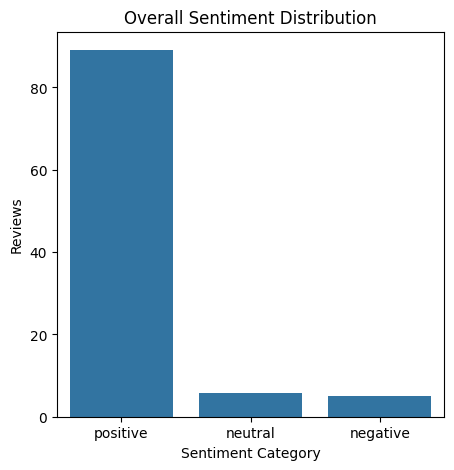

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5,5))
sns.barplot(x=sentiment_counts.index,y=sentiment_counts.values)
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment Category")
plt.ylabel("Reviews")


### Top 5 Praised, Complaint and Mentioned Features

In [35]:
top_praised,top_complaint,most_mentioned=top_features(df)
print("Top Features for Positive Reviews")
print(top_praised)
print("Top Features for Negative Reviews")
print(top_complaint)
print("Most Mentioned Features")
print(most_mentioned)

Top Features for Positive Reviews
features
price        5533
batteries    4693
value        1492
quality      1369
screen       1276
Name: count, dtype: int64
Top Features for Negative Reviews
features
batteries    615
price        136
quality       85
screen        51
charging      35
Name: count, dtype: int64
Most Mentioned Features
features
price        5788
batteries    5786
value        1503
quality      1501
screen       1332
Name: count, dtype: int64


### Level 2: Product Category wise Sentiment Analysis

### Sentiment Distribution

In [36]:
category_sentiment=df.groupby(['primaryCategories','vader_sentiment']).size()
category_sentiment

primaryCategories            vader_sentiment
Animals & Pet Supplies       positive               6
Electronics                  negative             415
                             neutral              162
                             positive           13418
Electronics,Furniture        positive               2
Electronics,Media            negative               2
                             positive             183
Health & Beauty              negative             978
                             neutral             1459
                             positive            9634
Home & Garden                neutral                1
                             positive               1
Office Supplies              neutral                1
                             positive               8
Office Supplies,Electronics  negative               8
                             neutral                4
                             positive             374
Toys & Games,Electronics     negative              42
                             neutral               18
                             positive            1616
dtype: int64

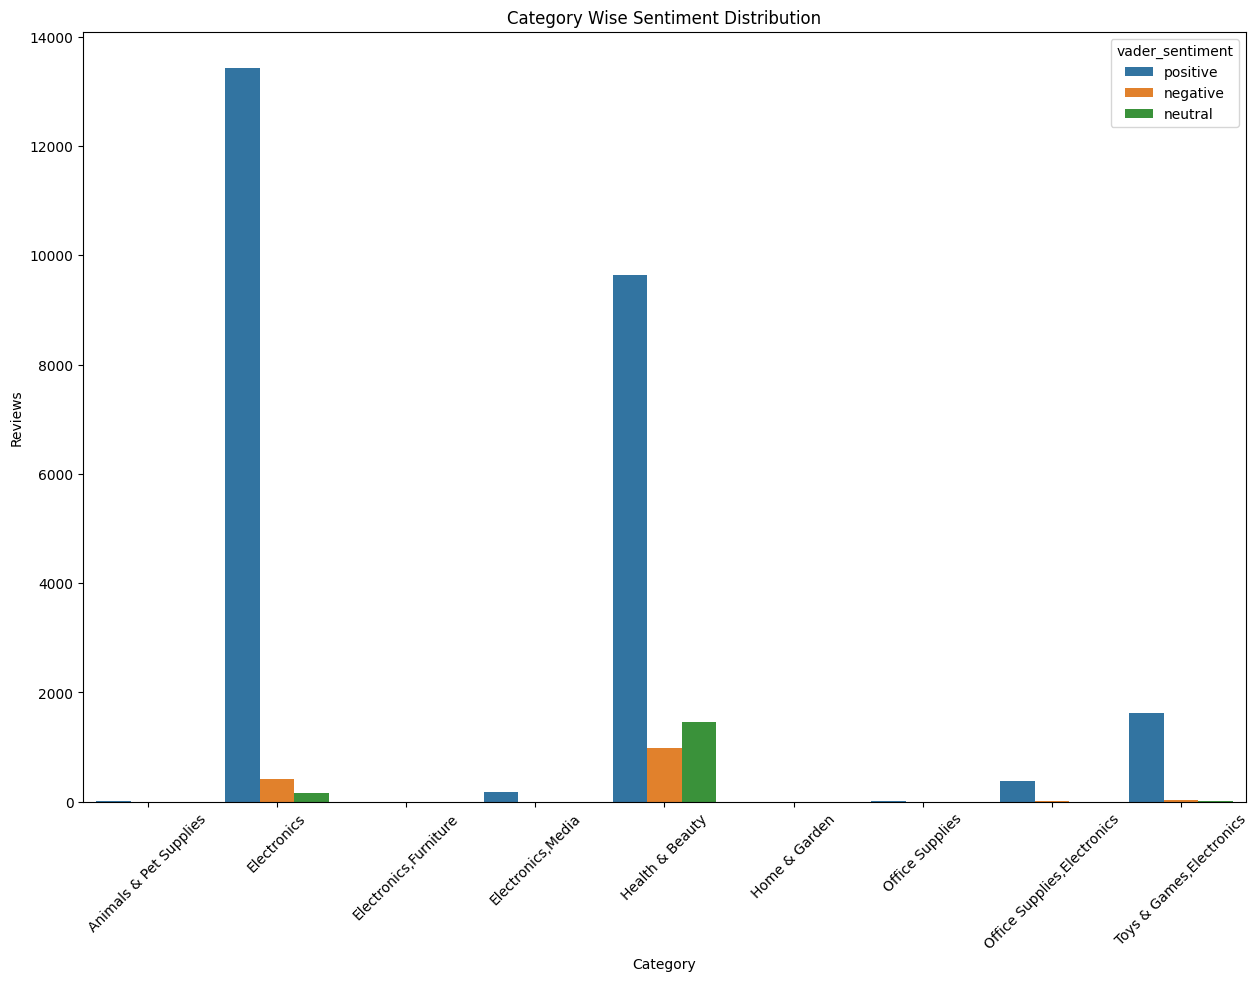

In [37]:
plt.figure(figsize=(15,10))
sns.barplot(x=category_sentiment.index.get_level_values(0),y=category_sentiment.values,hue=category_sentiment.index.get_level_values(1))
plt.title("Category Wise Sentiment Distribution")
plt.xlabel("Category")
plt.ylabel("Reviews")
plt.xticks(rotation=45)
plt.show()

### Top 5 Praised, Complaint and Mentioned Features

In [38]:
categories=df['primaryCategories'].explode().unique()
for cat in categories:
  print(f"Category: {cat}")
  top_praised,top_complaint,most_mentioned=top_features(df[df['primaryCategories']==cat])
  print("Top Features for Positive Reviews")
  print(top_praised if len(top_praised) else "No Positive Reviews")
  print("Top Features for Negative Reviews")
  print(top_complaint if len(top_complaint) else "No Negative Reviews")
  print("Most Mentioned Features")
  print(most_mentioned if len(most_mentioned) else "No Features Mentioned")
  print("\n")

Category: Health & Beauty
Top Features for Positive Reviews
features
batteries    4693
price        3067
value        1011
quality       751
packaging     486
Name: count, dtype: int64
Top Features for Negative Reviews
features
batteries    615
price         84
quality       60
packaging     16
usage          9
Name: count, dtype: int64
Most Mentioned Features
features
batteries    5786
price        3255
value        1018
quality       852
packaging     514
Name: count, dtype: int64


Category: Electronics
Top Features for Positive Reviews
features
price      2288
screen     1126
battery     616
quality     567
value       455
Name: count, dtype: int64
Top Features for Negative Reviews
features
price       51
screen      46
charging    32
battery     28
quality     20
Name: count, dtype: int64
Most Mentioned Features
features
price      2354
screen     1176
battery     649
quality     593
value       459
Name: count, dtype: int64


Category: Office Supplies
Top Features for Positive Re

### Level 3: Brand wise Sentiment Analysis

### Sentiment Distribution

In [39]:
brand_sentiment=df.groupby(['brand','vader_sentiment']).size()
brand_sentiment

brand         vader_sentiment
Amazon        negative             465
              neutral              180
              positive           15508
AmazonBasics  negative             980
              neutral             1465
              positive            9734
dtype: int64

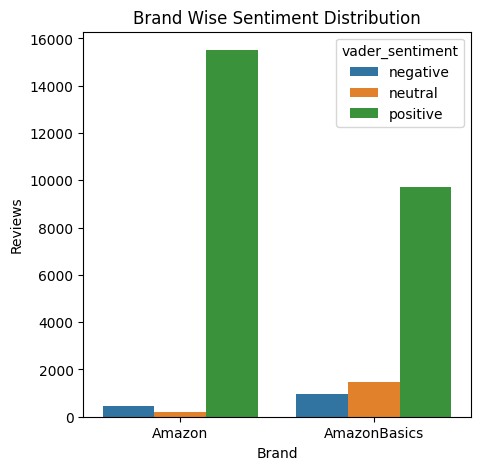

In [40]:
plt.figure(figsize=(5,5))
sns.barplot(x=brand_sentiment.index.get_level_values(0),y=brand_sentiment.values,hue=brand_sentiment.index.get_level_values(1))
plt.title("Brand Wise Sentiment Distribution")
plt.xlabel("Brand")
plt.ylabel("Reviews")
plt.show()

### Top 5 Praised, Complaint and Mentioned Features

In [41]:
brands=df['brand'].explode().unique()
for brand in brands:
  print(f"Brand: {brand}")
  top_praised,top_complaint,most_mentioned=top_features(df[df['brand']==brand])
  print("Top Features for Positive Reviews")
  print(top_praised if len(top_praised) else "No Positive Reviews")
  print("Top Features for Negative Reviews")
  print(top_complaint if len(top_complaint) else "No Negative Reviews")
  print("Most Mentioned Features")
  print(most_mentioned if len(most_mentioned) else "No Features Mentioned")
  print("\n")

Brand: AmazonBasics
Top Features for Positive Reviews
features
batteries    4693
price        3093
value        1021
quality       770
packaging     486
Name: count, dtype: int64
Top Features for Negative Reviews
features
batteries    615
price         84
quality       60
packaging     16
usage          9
Name: count, dtype: int64
Most Mentioned Features
features
batteries    5786
price        3281
value        1028
quality       872
packaging     514
Name: count, dtype: int64


Brand: Amazon
Top Features for Positive Reviews
features
price      2440
screen     1274
battery     787
quality     599
value       471
Name: count, dtype: int64
Top Features for Negative Reviews
features
price       52
screen      49
charging    35
battery     35
quality     25
Name: count, dtype: int64
Most Mentioned Features
features
price      2507
screen     1328
battery     829
quality     629
value       475
Name: count, dtype: int64




### Level 4: Model wise Sentiment Analysis

### Sentiment Distribution

In [42]:
model_sentiment=df.groupby(['name','vader_sentiment']).size().reset_index(name='count')
model_sentiment.head()

,name,vader_sentiment,count
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, 8 GB - Marine Blue",negative,1
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, 8 GB - Marine Blue",neutral,1
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, 8 GB - Marine Blue",positive,80
3,"All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Blue Kid-Proof Case",negative,9
4,"All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Blue Kid-Proof Case",neutral,3


### Checking Distribution for Top 5 Models Due to large number of Models

In [43]:
top_models=model_sentiment.groupby('name')['count'].sum().nlargest(5).index
top_models

Index(['AmazonBasics AAA Performance Alkaline Batteries (36 Count)',
       'AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary',
       'Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Tangerine - with Special Offers',
       'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Black',
       'Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Pink Kid-Proof Case'],
      dtype='object', name='name')

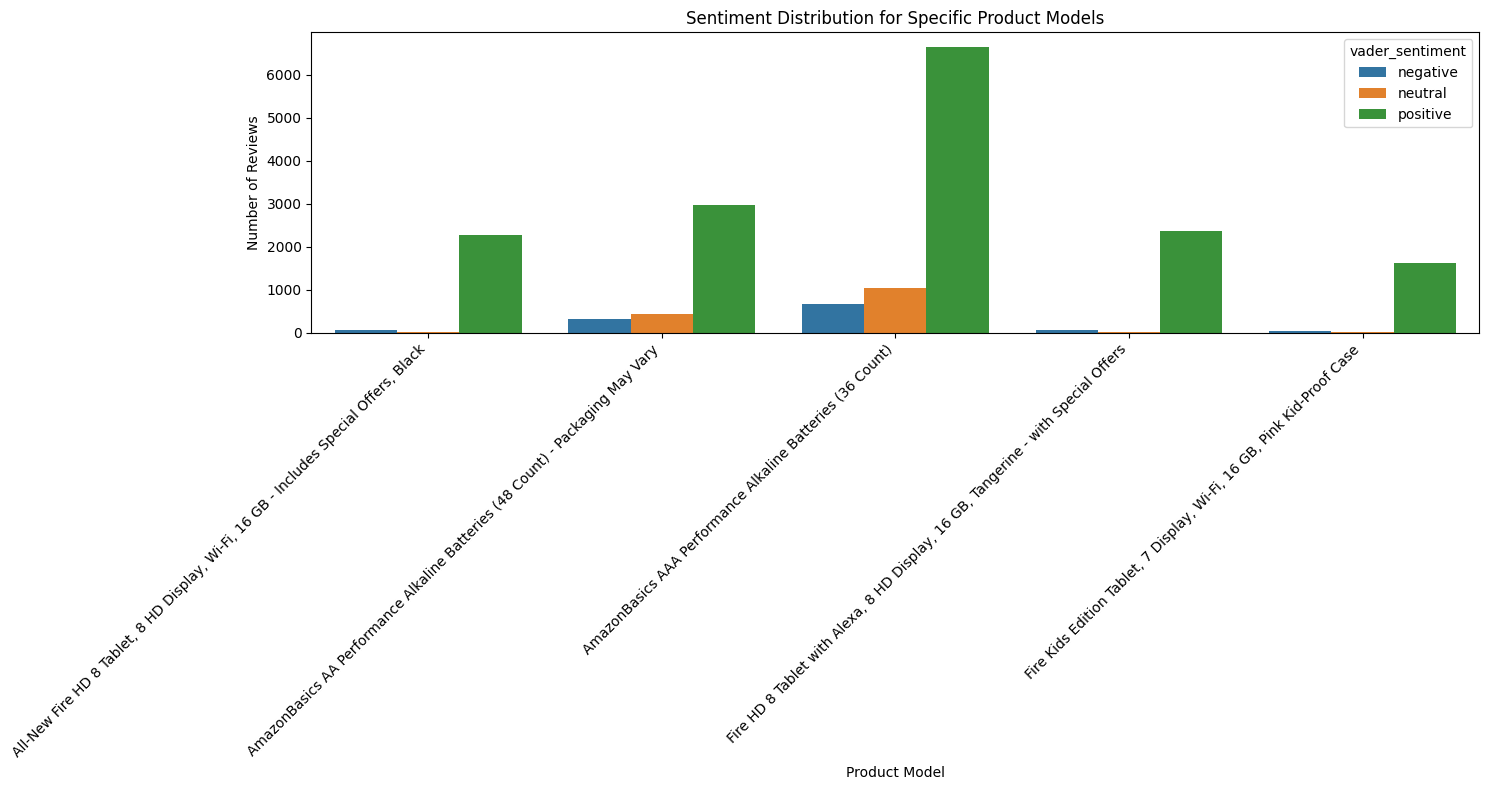

In [44]:
plt.figure(figsize=(15, 8))
sns.barplot(x='name',y='count',hue='vader_sentiment',data=model_sentiment[model_sentiment['name'].isin(top_models)])
plt.title('Sentiment Distribution for Specific Product Models')
plt.xlabel('Product Model')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Top 5 Praised, Complaint and Mentioned Features

In [45]:
for model in top_models:
  print(f"Model: {model}")
  top_praised,top_complaint,most_mentioned=top_features(df[df['name']==model])
  print("Top Features for Positive Reviews")
  print(top_praised if len(top_praised) else "No Positive Reviews")
  print("Top Features for Negative Reviews")
  print(top_complaint if len(top_complaint) else "No Negative Reviews")
  print("Most Mentionedhttp://qwone.com/~jason/20Newsgroups/ Features")
  print(most_mentioned if len(most_mentioned) else "No Features Mentioned")
  print("\n")

Model: AmazonBasics AAA Performance Alkaline Batteries (36 Count)
Top Features for Positive Reviews
features
batteries    3232
price        2135
value         704
quality       519
packaging     348
Name: count, dtype: int64
Top Features for Negative Reviews
features
batteries    410
price         56
quality       45
packaging     10
usage          6
Name: count, dtype: int64
Most Mentionedhttp://qwone.com/~jason/20Newsgroups/ Features
features
batteries    3986
price        2268
value         709
quality       592
packaging     366
Name: count, dtype: int64


Model: AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary
Top Features for Positive Reviews
features
batteries    1461
price         932
value         307
quality       232
packaging     138
Name: count, dtype: int64
Top Features for Negative Reviews
features
batteries    205
price         28
quality       15
packaging      6
usage          3
Name: count, dtype: int64
Most Mentionedhttp://qwone.com/~ja

In [46]:
df['reviews.numHelpful'].value_counts()

,count
reviews.numHelpful,
0.0,14878
1.0,589
2.0,256
3.0,82
4.0,58
...,...
525.0,1
288.0,1
47.0,1


### Model Accuracy without validation with amazon helpful votes

In [47]:
accuracy_score(df['rating_sentiment'],df['vader_sentiment'])

0.8737822956374418

### Accuracy Improvement with Amazon Helpful votes

In [48]:
reviewed_prod=df[df['reviews.numHelpful']>0]
accuracy_score(reviewed_prod['rating_sentiment'],reviewed_prod['vader_sentiment'])

0.9143088116410671

### Conclusion
#### Accuracy for VADER Scores on Reviews Text Alone: 83.21%
#### Accuracy for VADER Scores on Reviews+Title: 87.05%
#### Accuracy for VADER Scores on Preprocessed text(Reviews+Title) by removing stop words and lemmatizing: 87.38%
#### Accuracy for VADER Scores on Filtering out based on helpful votes(>0) : 91.43%